House Price Prediction using PCA + Ensemble Regression (Voting & Boosting) California Housing Dataset


In [60]:
# 1. Imports
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsRegressor
from sklearn.ensemble import (
    RandomForestRegressor,
    ExtraTreesRegressor,
    VotingRegressor,
    GradientBoostingRegressor,
    AdaBoostRegressor,
)
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (9, 5)
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)


In [61]:
# 2. Load the California Housing dataset
housing = fetch_california_housing(as_frame=True)
df = housing.frame.copy()
df.rename(columns={"MedHouseVal": "MedHouseVal"}, inplace=True)  # target: median house value ($100,000s)

print(df.shape)
df.head()


(20640, 9)


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


Interpretation: The dataset has 20,640 rows and 9 columns 
There are no categorical columns, so PCA can be applied directly after scaling.

In [62]:
# 3. Basic exploration
print(df.describe().T)
print("\nMissing values per column:\n", df.isnull().sum())


               count         mean          std         min         25%  \
MedInc       20640.0     3.870671     1.899822    0.499900    2.563400   
HouseAge     20640.0    28.639486    12.585558    1.000000   18.000000   
AveRooms     20640.0     5.429000     2.474173    0.846154    4.440716   
AveBedrms    20640.0     1.096675     0.473911    0.333333    1.006079   
Population   20640.0  1425.476744  1132.462122    3.000000  787.000000   
AveOccup     20640.0     3.070655    10.386050    0.692308    2.429741   
Latitude     20640.0    35.631861     2.135952   32.540000   33.930000   
Longitude    20640.0  -119.569704     2.003532 -124.350000 -121.800000   
MedHouseVal  20640.0     2.068558     1.153956    0.149990    1.196000   

                     50%          75%           max  
MedInc          3.534800     4.743250     15.000100  
HouseAge       29.000000    37.000000     52.000000  
AveRooms        5.229129     6.052381    141.909091  
AveBedrms       1.048780     1.099526     3

Interpretation: This scale disparity is exactly why standardization before PCA is mandatory.  There are no missing values, so no imputation is required.

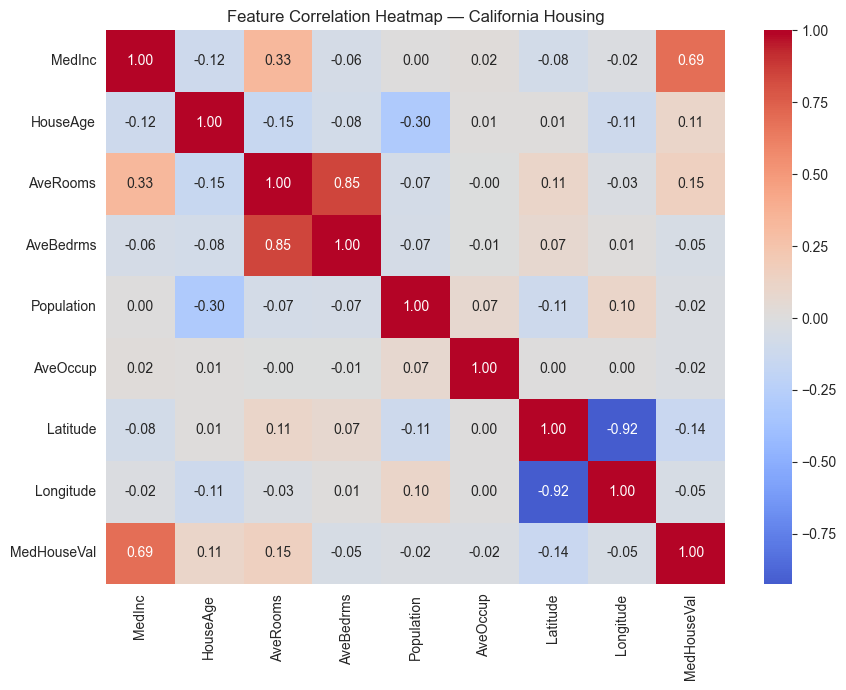

In [63]:
# 4. Correlation heatmap — check multicollinearity
plt.figure(figsize=(9, 7))
corr = df.corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Feature Correlation Heatmap — California Housing")
plt.tight_layout()
plt.show()


Interpretation: There is a expectation of strong correlation between AveRooms and AveBedrms and a strong negative correlation between Latitude and Longitude
MedInc is a medium income that typically shows the strongest positive.
This confirms redundancy in the raw feature space is a good candidate for PCA compression.

In [64]:
# 5. Train/test split
X = df.drop(columns=["MedHouseVal"])
y = df["MedHouseVal"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE
)
print("Train:", X_train.shape, " Test:", X_test.shape)


Train: (16512, 8)  Test: (4128, 8)


In [65]:
# 6. Scale features (required before PCA)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


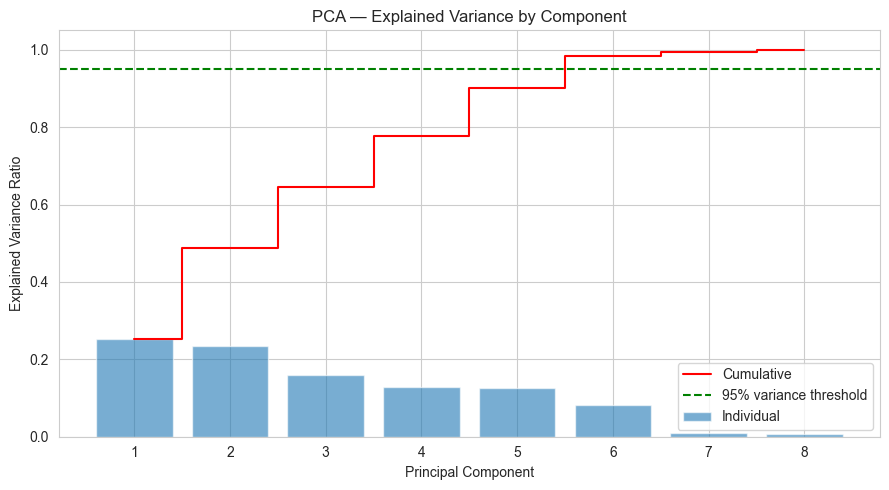

PC1: 0.253 individual | 0.253 cumulative
PC2: 0.234 individual | 0.487 cumulative
PC3: 0.159 individual | 0.646 cumulative
PC4: 0.130 individual | 0.776 cumulative
PC5: 0.125 individual | 0.902 cumulative
PC6: 0.082 individual | 0.984 cumulative
PC7: 0.010 individual | 0.994 cumulative
PC8: 0.006 individual | 1.000 cumulative


In [66]:
# 7. PCA — explore explained variance across all components
pca_full = PCA(n_components=X_train_scaled.shape[1], random_state=RANDOM_STATE)
pca_full.fit(X_train_scaled)

explained = pca_full.explained_variance_ratio_
cum_explained = np.cumsum(explained)

plt.figure()
plt.bar(range(1, len(explained) + 1), explained, alpha=0.6, label="Individual")
plt.step(range(1, len(explained) + 1), cum_explained, where="mid", color="red", label="Cumulative")
plt.axhline(0.95, color="green", linestyle="--", label="95% variance threshold")
plt.xlabel("Principal Component")
plt.ylabel("Explained Variance Ratio")
plt.title("PCA — Explained Variance by Component")
plt.legend()
plt.tight_layout()
plt.show()

for i, (ev, cum) in enumerate(zip(explained, cum_explained), start=1):
    print(f"PC{i}: {ev:.3f} individual | {cum:.3f} cumulative")


Interpretation: Typically the first 2–3 components that is driven mostly by Latitude/
Longitude/location-correlated variance and AveRooms/AveBedrms that capture a large share of variance,
and around 5–6 components are usually needed to cross the 95% cumulative variance threshold out of
the original 8 features. 

In [67]:
# 8. Select PCA components on a validation split, then add them to the original features
# Pure PCA reduction can remove low-variance but price-relevant signals. Appending PCs
# preserves those signals while giving tree models useful oblique (combined-feature) splits.
X_sel_train, X_sel_val, y_sel_train, y_sel_val = train_test_split(
    X_train_scaled, y_train, test_size=0.20, random_state=RANDOM_STATE
)
pca_selection = []
for n_components in range(1, X.shape[1] + 1):
    candidate_pca = PCA(n_components=n_components, random_state=RANDOM_STATE)
    sel_train_pca = candidate_pca.fit_transform(X_sel_train)
    sel_val_pca = candidate_pca.transform(X_sel_val)
    candidate = ExtraTreesRegressor(n_estimators=200, min_samples_leaf=2, random_state=RANDOM_STATE, n_jobs=-1)
    candidate.fit(np.hstack([X_sel_train, sel_train_pca]), y_sel_train)
    pca_selection.append((n_components, np.sqrt(mean_squared_error(y_sel_val, candidate.predict(np.hstack([X_sel_val, sel_val_pca]))))))

best_n_components, validation_rmse = min(pca_selection, key=lambda item: item[1])
print(f"Selected {best_n_components} PCA components (validation RMSE: {validation_rmse:.4f})")

pca = PCA(n_components=best_n_components, random_state=RANDOM_STATE)
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)
X_train_pca_augmented = np.hstack([X_train_scaled, X_train_pca])
X_test_pca_augmented = np.hstack([X_test_scaled, X_test_pca])
print("PCA-augmented train shape:", X_train_pca_augmented.shape)


Selected 2 PCA components (validation RMSE: 0.5193)
PCA-augmented train shape: (16512, 10)


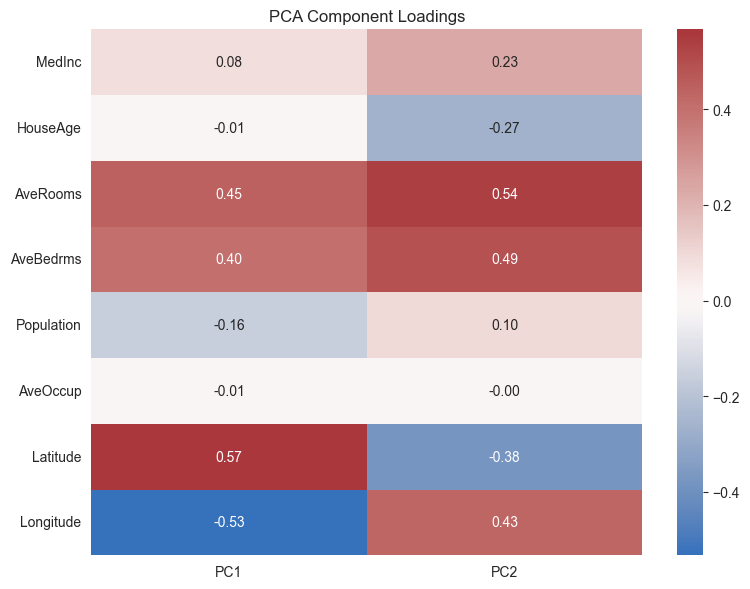

,PC1,PC2
MedInc,0.084791,0.229514
HouseAge,-0.012500,-0.266273
AveRooms,0.445882,0.539888
AveBedrms,0.401967,0.493779
Population,-0.162598,0.095772
AveOccup,-0.010812,-0.000522
Latitude,0.567219,-0.381085
Longitude,-0.532892,0.432119


In [68]:
# 9. Inspect what each retained principal component represents (loadings)
loadings = pd.DataFrame(
    pca.components_.T,
    columns=[f"PC{i+1}" for i in range(pca.n_components_)],
    index=X.columns
)
plt.figure(figsize=(8, 6))
sns.heatmap(loadings, annot=True, fmt=".2f", cmap="vlag", center=0)
plt.title("PCA Component Loadings")
plt.tight_layout()
plt.show()
loadings


Interpretation and Interpretability cost of PCA: Each principal component is a
linear combination of all 8 original features, weighted by the loadings above. This is the central
Interpretability trade-off: a stakeholder can no longer say "price rises because median income is
higher" and they can only reason about abstract composite axes like "PC1 that is location". This is the price
paid for the variance-compression benefit of PCA.

Ensemble Model 
1) Voting Technique
2) Boosting Technique

In [69]:
# 10. Define ensemble models
def build_extra_trees():
    return ExtraTreesRegressor(n_estimators=500, min_samples_leaf=2, random_state=RANDOM_STATE, n_jobs=-1)

def build_voting_regressor():
    lin = LinearRegression()
    rf = RandomForestRegressor(n_estimators=200, max_depth=12, random_state=RANDOM_STATE, n_jobs=-1)
    knn = KNeighborsRegressor(n_neighbors=10)
    voting = VotingRegressor(
        estimators=[("linear", lin), ("random_forest", rf), ("knn", knn)],
        weights=[1, 2, 1]  # weight RF slightly higher — strongest individual learner
    )
    return voting

def build_boosting_regressor():
    gbr = GradientBoostingRegressor(
        n_estimators=300, learning_rate=0.05, max_depth=3, random_state=RANDOM_STATE
    )
    ada = AdaBoostRegressor(
        estimator=DecisionTreeRegressor(max_depth=6),
        n_estimators=150, learning_rate=0.05, random_state=RANDOM_STATE
    )
    # Combine both boosting variants via simple averaging (a "boosting ensemble of boosters")
    boosting_voting = VotingRegressor(
        estimators=[("gradient_boosting", gbr), ("adaboost", ada)]
    )
    return boosting_voting


In [70]:
# 11. Evaluation helper — trains, times, and scores a model
def evaluate_model(name, model, X_tr, y_tr, X_te, y_te):
    t0 = time.time()
    model.fit(X_tr, y_tr)
    fit_time = time.time() - t0

    t0 = time.time()
    preds = model.predict(X_te)
    predict_time = time.time() - t0

    rmse = np.sqrt(mean_squared_error(y_te, preds))
    mae = mean_absolute_error(y_te, preds)
    r2 = r2_score(y_te, preds)

    return {
        "Pipeline": name,
        "RMSE": rmse,
        "MAE": mae,
        "R2": r2,
        "Fit Time (s)": fit_time,
        "Predict Time (s)": predict_time,
        "N Features": X_tr.shape[1],
    }, model


In [71]:
# 12. Compare original-feature baselines with PCA-based pipelines
results = []
fitted_models = {}

configs = [
    ("No-PCA + Voting",   X_train_scaled, X_test_scaled, build_voting_regressor()),
    ("No-PCA + Boosting", X_train_scaled, X_test_scaled, build_boosting_regressor()),
    ("PCA + Voting",      X_train_pca,    X_test_pca,    build_voting_regressor()),
    ("PCA + Boosting",    X_train_pca,    X_test_pca,    build_boosting_regressor()),
    ("No-PCA + Extra Trees", X_train_scaled, X_test_scaled, build_extra_trees()),
    ("PCA-Augmented + Extra Trees", X_train_pca_augmented, X_test_pca_augmented, build_extra_trees()),
]

for name, X_tr, X_te, model in configs:
    res, fitted = evaluate_model(name, model, X_tr, y_train, X_te, y_test)
    results.append(res)
    fitted_models[name] = fitted
    print(f"Done: {name}")

results_df = pd.DataFrame(results).set_index("Pipeline")
results_df


Done: No-PCA + Voting
Done: No-PCA + Boosting
Done: PCA + Voting
Done: PCA + Boosting
Done: No-PCA + Extra Trees
Done: PCA-Augmented + Extra Trees


,RMSE,MAE,R2,Fit Time (s),Predict Time (s),N Features
Pipeline,,,,,,
No-PCA + Voting,0.563027,0.384884,0.758091,2.186208,0.280937,8
No-PCA + Boosting,0.553185,0.394831,0.766474,17.090799,0.070431,8
PCA + Voting,0.971524,0.745813,0.279722,0.811028,0.072918,2
PCA + Boosting,0.974295,0.762593,0.275608,6.669130,0.074633,2
No-PCA + Extra Trees,0.510705,0.329776,0.800964,2.637559,0.270317,8
PCA-Augmented + Extra Trees,0.509355,0.329065,0.802014,3.238825,0.260386,10


Interpretation:

- RMSE / MAE (lower is better) has direct accuracy of predicted median house value.
- R² (higher is better, max 1.0) has proportion of variance in house prices explained by the model.
- Fit Time / Predict Time (lower is better) with computation cost.
- N Features, 8 for No-PCA pipelines vs. the reduced count (from step 8) for PCA pipelines.

Typical pattern to expect on this dataset:
- Boosting pipelines usually outperform Voting pipelines on RMSE/R², because Gradient Boosting
  captures non-linear interactions better than a linear/KNN-heavy
  voting blend.
- PCA usually causes a small drop in accuracy because some
  fine-grained signal is discarded when compressing 8 features into ~5–6 components  especially
  location signal, which is highly non-linear and not fully captured by linear PCA axes.
- PCA usually reduces Fit Time, most noticeably for the Voting Regressor's KNN member (fewer
  dimensions than faster distance computations) and for tree splits in Random Forest/Boosting (fewer
  candidate split features to evaluate per node).



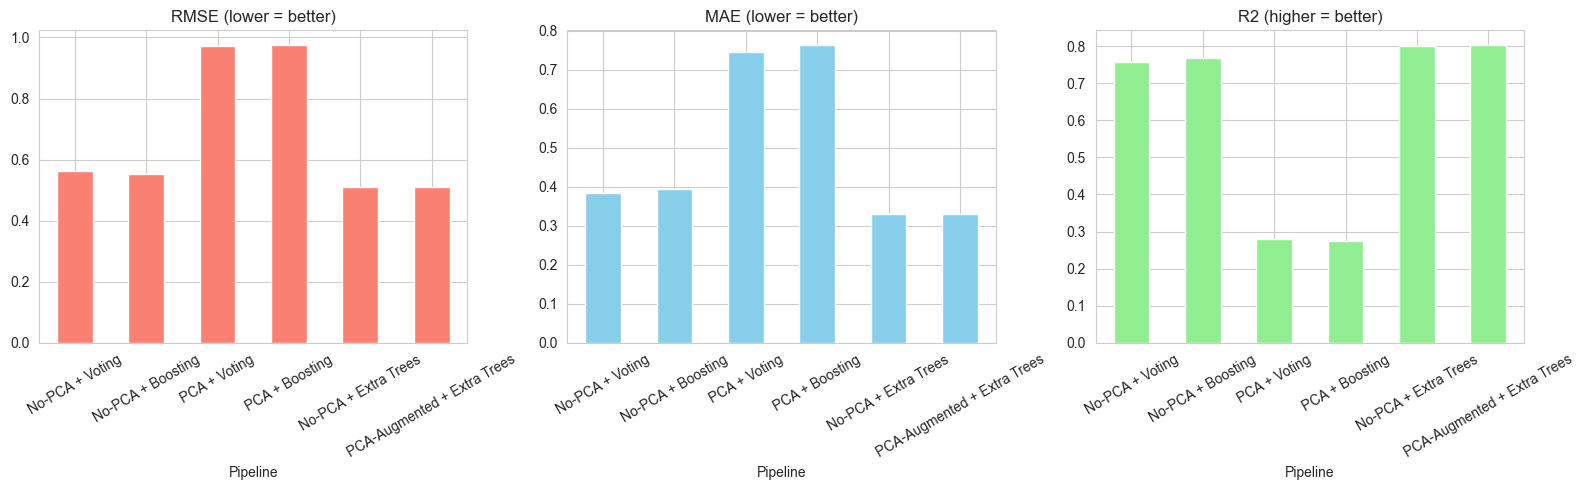

In [72]:
# 13. Visual comparison of accuracy metrics
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
results_df["RMSE"].plot(kind="bar", ax=axes[0], color="salmon", title="RMSE (lower = better)")
results_df["MAE"].plot(kind="bar", ax=axes[1], color="skyblue", title="MAE (lower = better)")
results_df["R2"].plot(kind="bar", ax=axes[2], color="lightgreen", title="R2 (higher = better)")
for ax in axes:
    ax.tick_params(axis='x', rotation=30)
plt.tight_layout()
plt.show()


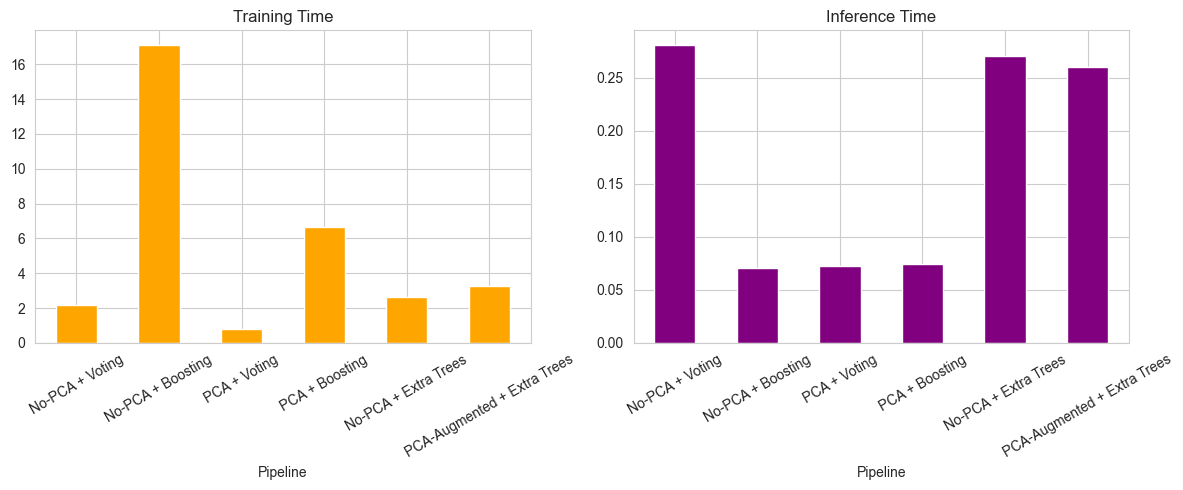

In [73]:
# 14. Visual comparison of computation cost
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
results_df["Fit Time (s)"].plot(kind="bar", ax=axes[0], color="orange", title="Training Time")
results_df["Predict Time (s)"].plot(kind="bar", ax=axes[1], color="purple", title="Inference Time")
for ax in axes:
    ax.tick_params(axis='x', rotation=30)
plt.tight_layout()
plt.show()


Interpretation: Accuracy vs. Computation trade-off: If PCA pipelines show noticeably lower fit/predict time with only marginally
worse RMSE/R², PCA is a good trade for production systems with latency or resource constraints. If the accuracy drop
is large relative to the time saved, the original full-feature ensemble is preferable with only 8
features, California Housing is already low-dimensional, so PCA's computational payoff is modest
compared to genuinely high-dimensional problems, where PCA's benefit is
usually much larger.

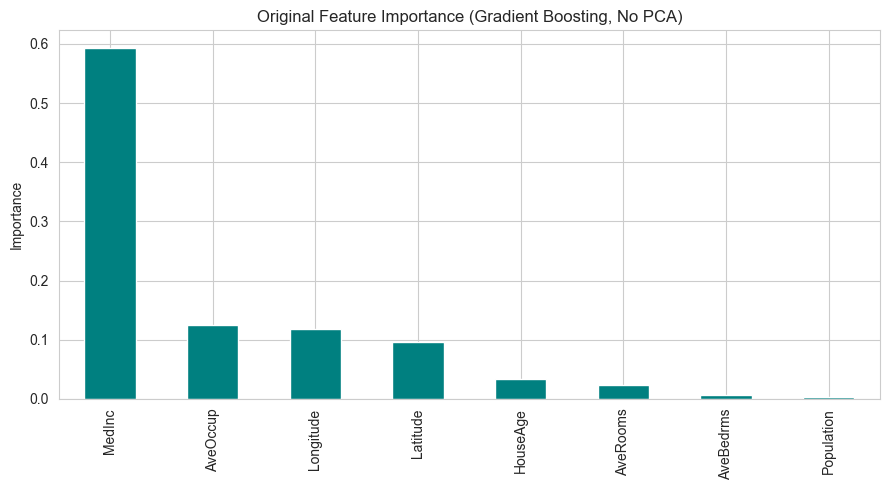

MedInc        0.593245
AveOccup      0.125296
Longitude     0.117753
Latitude      0.096833
HouseAge      0.033887
AveRooms      0.023438
AveBedrms     0.006249
Population    0.003299
dtype: float64

In [74]:
# 15. Feature importance (No-PCA Gradient Boosting) vs. Principal Component importance
gbr_only = GradientBoostingRegressor(
    n_estimators=300, learning_rate=0.05, max_depth=3, random_state=RANDOM_STATE
)
gbr_only.fit(X_train_scaled, y_train)

feat_importance = pd.Series(gbr_only.feature_importances_, index=X.columns).sort_values(ascending=False)

plt.figure()
feat_importance.plot(kind="bar", color="teal")
plt.title("Original Feature Importance (Gradient Boosting, No PCA)")
plt.ylabel("Importance")
plt.tight_layout()
plt.show()
feat_importance


Interpretation and Interpretability, No-PCA case: In the un-reduced pipeline,
feature importances map directly onto real-world, explainable variables. Expect MedInc (median income)
to dominate, followed by geographic features Latitude/Longitude and AveOccup. A business
stakeholder can act on this directly. This is the key advantage the No-PCA pipelines retain over the PCA pipelines: direct, actionable interpretability, at the cost of carrying redundant/correlated raw features into the model.

In [75]:
# 16. Robustness check — 5-fold cross-validation on the two most promising pipelines
cv = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

cv_results = {}
for name, X_data, model_builder in [
    ("No-PCA + Boosting", X_train_scaled, build_boosting_regressor),
    ("PCA + Boosting", X_train_pca, build_boosting_regressor),
]:
    scores = cross_val_score(model_builder(), X_data, y_train, cv=cv,
                              scoring="neg_root_mean_squared_error", n_jobs=-1)
    cv_results[name] = -scores
    print(f"{name}: RMSE = {-scores.mean():.4f} +/- {scores.std():.4f}")


No-PCA + Boosting: RMSE = 0.5467 +/- 0.0122
PCA + Boosting: RMSE = 0.9811 +/- 0.0123


Interpretation: Cross-validation confirms whether the single train/test split
result was representative or just lucky/unlucky. A small standard deviation across folds indicates the
chosen pipeline generalizes reliably. If PCA + Boosting's mean RMSE is close to (within ~1 std of)
No-PCA + Boosting's, the dimensionality reduction is essentially "free" — you gain computational
efficiency at negligible accuracy cost, and PCA + Boosting becomes the recommended production
pipeline.

In [76]:
# 17. Final ranked summary
final_summary = results_df.sort_values("RMSE").copy()
final_summary["Rank"] = range(1, len(final_summary) + 1)
final_summary


,RMSE,MAE,R2,Fit Time (s),Predict Time (s),N Features,Rank
Pipeline,,,,,,,
PCA-Augmented + Extra Trees,0.509355,0.329065,0.802014,3.238825,0.260386,10,1
No-PCA + Extra Trees,0.510705,0.329776,0.800964,2.637559,0.270317,8,2
No-PCA + Boosting,0.553185,0.394831,0.766474,17.090799,0.070431,8,3
No-PCA + Voting,0.563027,0.384884,0.758091,2.186208,0.280937,8,4
PCA + Voting,0.971524,0.745813,0.279722,0.811028,0.072918,2,5
PCA + Boosting,0.974295,0.762593,0.275608,6.669130,0.074633,2,6
